# Application 6 — Deformation Localization via PCA

Given a population of shapes, **which regions deform the most across subjects?**

Strategy:
1. Pick a template shape.
2. Register each shape to the template via a functional map.
3. Transfer a per-vertex signal (here: radial distance from centroid) to the template domain.
4. Stack transferred signals into a matrix and run PCA.
5. The principal components reveal the dominant modes of shape variation, localised on the template.

This notebook uses cardiac LV shapes (ACDC).  Set `DATA_ROOT` below.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

from geomfum.dataset import AcdcDataset

pv.set_jupyter_backend("static")

## 1. Load a collection of shapes

> Set `DATA_ROOT` to your ACDC directory, or replace the loading block with any
> list of `TriangleMesh` objects.

In [2]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
DATA_ROOT = "../../../../ACDC/database/training/"  # TODO: set your ACDC data path
GROUP = "NOR"  # load shapes from one group
N_SHAPES = 10  # total shapes (first one = template)
K_SPECTRUM = 30  # eigenfunctions per shape
# ─────────────────────────────────────────────────────────────────────────────
raw_meshes = []
ds = AcdcDataset(root=DATA_ROOT, groups=[GROUP])
for idx, (mesh_ed, mesh_es, meta) in enumerate(ds):
    if idx >= N_SHAPES:
        break
    mesh_ed.vertices -= np.mean(
        mesh_ed.vertices, axis=0
    )  # convert to gs array for later
    raw_meshes.append(mesh_ed)  # use end-diastole mesh (or mesh_es for end-systole)

print(f"Loaded {len(raw_meshes)} shapes")


Loaded 10 shapes


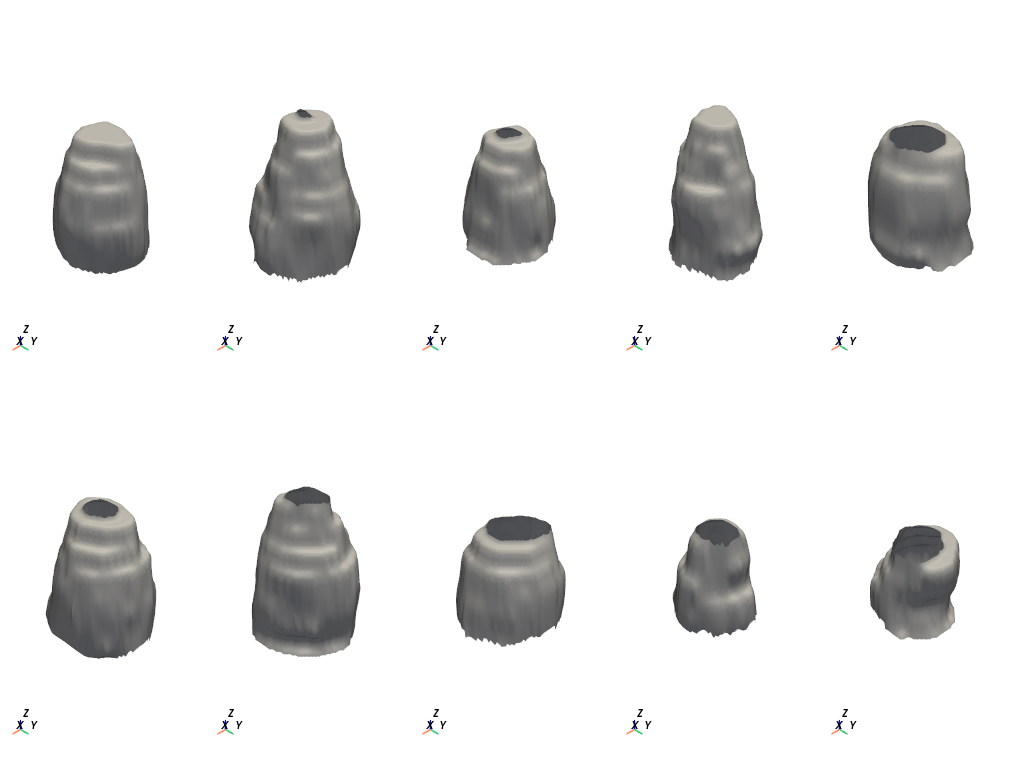

In [3]:
import sys
from pathlib import Path

import geomfum

notebooks_dir = Path(geomfum.__file__).resolve().parents[1] / "notebooks"
notebooks_dir_str = str(notebooks_dir)
if notebooks_dir_str not in sys.path:
    sys.path.insert(0, notebooks_dir_str)

from plot_utils import pv_faces, show_multiple_meshes  # noqa: E402

show_multiple_meshes(
    vertices_list=[m.vertices for m in raw_meshes],
    faces_list=[m.faces for m in raw_meshes],
    n_cols=5,
)

## 2. Compute spectral basis for all shapes

In [4]:
for i, mesh in enumerate(raw_meshes):
    mesh.laplacian.find_spectrum(spectrum_size=K_SPECTRUM, set_as_basis=True)

template = raw_meshes[0]
subjects = raw_meshes[1:]
print(f"Template: {template.n_vertices} vertices | Subjects: {len(subjects)}")

Template: 2631 vertices | Subjects: 9


## 3. Register each subject to the template and transfer a signal

We transfer the **radial distance** (distance from centroid) from each subject to the
template domain using the FM adjoint: `C^T` maps spectral coefficients from subject → template.

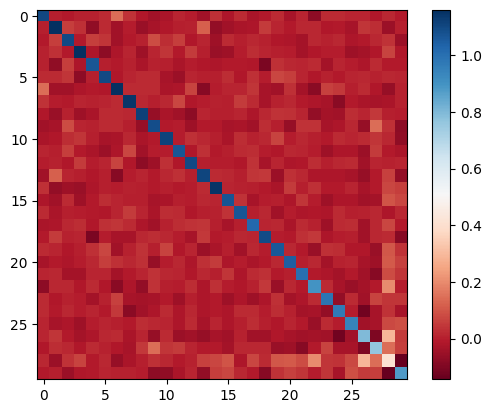

  Subject 1/9 done


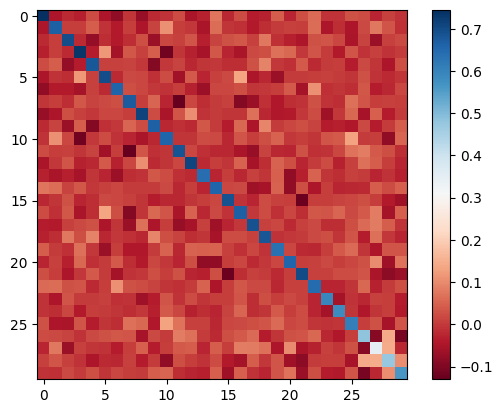

  Subject 2/9 done


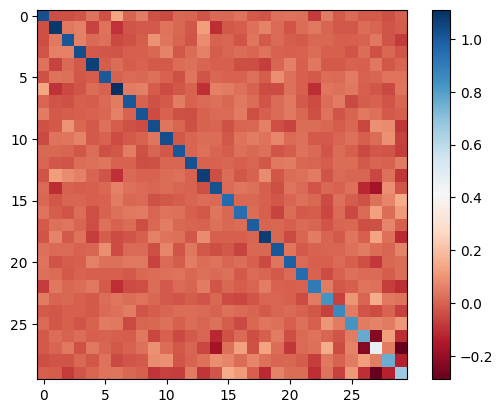

  Subject 3/9 done


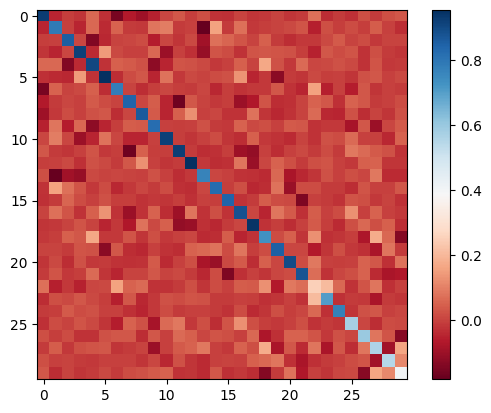

  Subject 4/9 done


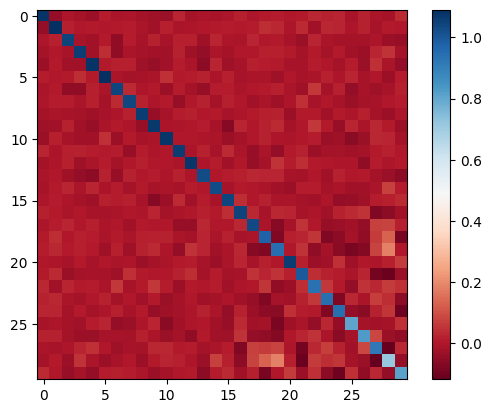

  Subject 5/9 done


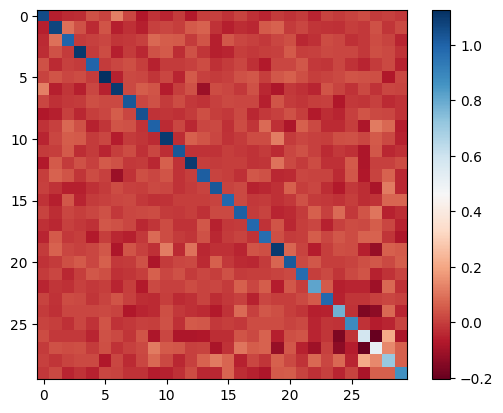

  Subject 6/9 done


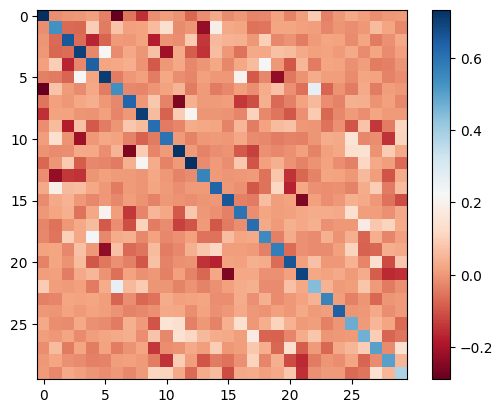

  Subject 7/9 done


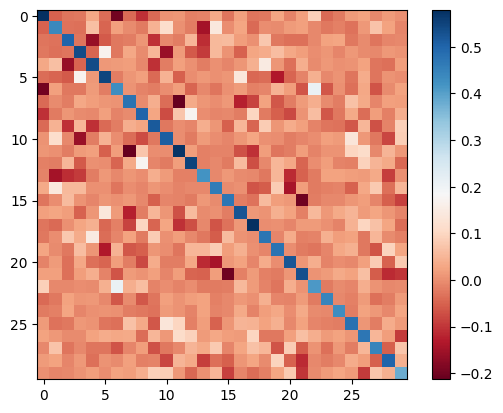

  Subject 8/9 done


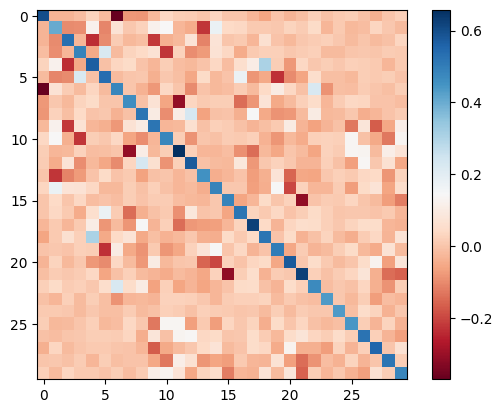

  Subject 9/9 done
Signal matrix: (9, 900)


In [5]:
from geomfum.convert import FmFromP2pConverter, NeighborFinder

knn = NeighborFinder()


def build_fm(mesh_a, mesh_b):
    """Build a functional map from mesh_a to mesh_b using nearest neighbor search on vertices and the FmFromP2pConverter."""
    p2p = knn(mesh_b.vertices, mesh_a.vertices).flatten()  # (n_a,)
    fmap_conv = FmFromP2pConverter()

    fmap = fmap_conv(
        p2p,
        mesh_a.basis,
        mesh_b.basis,
    )  # (K
    return fmap


signal_matrix = []  # rows = subjects, cols = template vertices

for i, subject in enumerate(subjects):
    # FM from template (A) to subject (B): shape (K_b, K_a)
    fmap = build_fm(template, subject)

    # shape difference operator from template to subject: shape (K_a, K_a)
    diff_op = fmap.T @ fmap
    plt.imshow(diff_op, cmap="RdBu")
    plt.colorbar()
    plt.show()
    # Spectral transfer from subject → template via FM^T
    signal_matrix.append(diff_op.reshape(-1))  # flatten to (K_a * K_a,)
    print(f"  Subject {i + 1}/{len(subjects)} done")

X = np.stack(signal_matrix)  # (n_subjects, n_template)
print(f"Signal matrix: {X.shape}")

## 4. PCA on the signal matrix

In [6]:
X.shape

(9, 900)

Variance explained by first 5 PCs:
  PC1: 78.2%
  PC2: 7.9%
  PC3: 4.5%
  PC4: 3.4%
  PC5: 1.9%


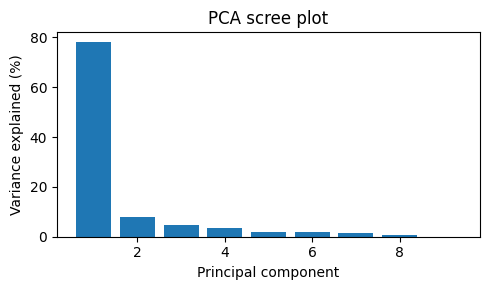

In [7]:
X_centered = X - X.mean(0)  # remove mean signal
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
variance_explained = (S**2) / (S**2).sum()

print("Variance explained by first 5 PCs:")
for i in range(min(5, len(S))):
    print(f"  PC{i + 1}: {100 * variance_explained[i]:.1f}%")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(1, min(10, len(S)) + 1), 100 * variance_explained[:10])
ax.set_xlabel("Principal component")
ax.set_ylabel("Variance explained (%)")
ax.set_title("PCA scree plot")
plt.tight_layout()
plt.show()

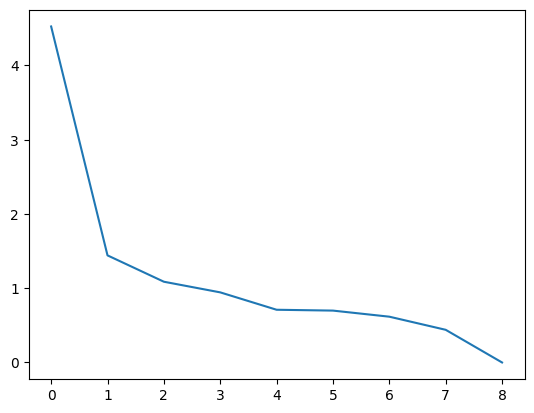

In [8]:
plt.plot(S)

## 5. Visualise principal deformation modes on the template

Each PC is a spatial map on the template: high values indicate regions that vary
most along that mode of deformation.

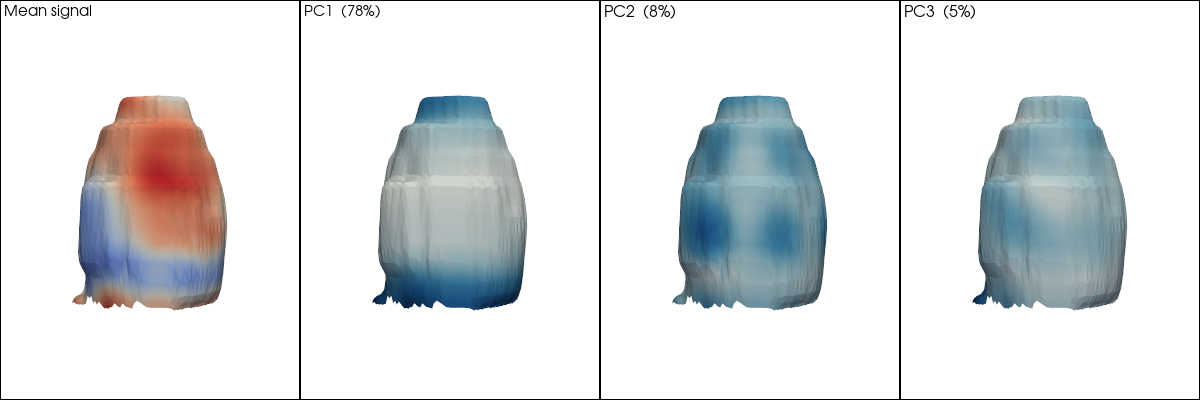

In [9]:
n_pcs = min(3, len(S))
pl = pv.Plotter(shape=(1, n_pcs + 1), window_size=(300 * (n_pcs + 1), 400))

pl.subplot(0, 0)
pv_t = pv.PolyData(np.array(template.vertices), pv_faces(template.faces))
pv_t["mean"] = template.basis.vecs @ X.mean(0).reshape(30, 30)
pl.add_mesh(pv_t, scalars="mean", cmap="coolwarm", show_scalar_bar=False)
pl.add_text("Mean signal", font_size=9)
pl.camera_position = "xz"

for pc_idx in range(n_pcs):
    pc_map = np.linalg.norm(template.basis.vecs @ Vt[pc_idx].reshape(30, 30), axis=1)
    pl.subplot(0, pc_idx + 1)
    pv_pc = pv.PolyData(np.array(template.vertices), pv_faces(template.faces))
    pv_pc[f"pc{pc_idx + 1}"] = pc_map
    pl.add_mesh(
        pv_pc,
        scalars=f"pc{pc_idx + 1}",
        cmap="RdBu",
        clim=[-np.abs(pc_map).max(), np.abs(pc_map).max()],
        show_scalar_bar=False,
    )
    pl.add_text(
        f"PC{pc_idx + 1}  ({100 * variance_explained[pc_idx]:.0f}%)", font_size=9
    )
    pl.camera_position = "xz"

pl.show()

Red/blue regions on each PC indicate areas of maximum deformation along that mode.
PC1 typically captures the dominant shape difference in the population (e.g., LV dilation
in DCM vs. concentric hypertrophy in HCM).